# Unknown cell type identification using scAdam

[**scAdam**](https://scparadise.readthedocs.io/en/latest/theory.html#scadam-models)  is specifically developed for annotating cell types, especially focusing on rare cell types that may be underrepresented in the dataset.

**Advantages**
1. scAdam not only detects all cell types in any test dataset but also generates reproducible results, which is an important aspect for reliable biological interpretation.
2. It enables multitasking by allowing the researchers to extract individual cell types for targeted investigations.
3. Unknown cell type identification makes it possible to identify new cell types that are absent from the data on which the scAdam model was trained. In addition, this enables cross-tissue cell type annotation, as demonstrated in this tutorial.

**Integration with Other Tools:** <br>
scAdam is part of a bigger toolkit that includes other tools, such as [**scEve**](https://scparadise.readthedocs.io/en/latest/theory.html#sceve-models) for surface protein prediction and [**scNoah**](https://scparadise.readthedocs.io/en/latest/theory.html#scnoah-metrics) for benchmarking, making it a comprehensive solution for single-cell analysis.

In [1]:
# Python packages
import warnings
warnings.simplefilter('ignore')

import scanpy as sc
import scparadise
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sc.set_figure_params(dpi = 80)

In [2]:
# Download example dataset from Figshare:
# https://figshare.com/ndownloader/files/62994628
# Use wget or simply paste the link into your browser to download.

In [3]:
# Load visceral adipose tissue dataset
adata = sc.read_h5ad('VAT_sample.h5ad')
adata

AnnData object with n_obs × n_vars = 16520 × 28137
    obs: 'sample', 'ground_truth'
    obsm: 'X_harmony', 'X_pca', 'X_umap'

In [4]:
# Saving count data
adata.layers['counts'] = adata.X.copy()
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [6]:
# Available models for cell type annotation
df = scparadise.scadam.available_models(query='Subcutaneous adipose tissue')
df

,Model name,Tissue/Organ,Species,Description,Suspension,Accuracy,Balanced Accuracy,Number of Levels
0,Human_Subcutaneous_AT,adipose,human,Subcutaneous adipose tissue atlas,cells,0.973,0.954,3


In [7]:
# Download model for cell type prediction
scparadise.scadam.download_model('Human_Subcutaneous_AT', save_path='')

In [8]:
# Predict cell types using scAdam model with unknown cell type identification
adata = scparadise.scadam.predict(
    adata,
    path_model = 'Human_Subcutaneous_AT_scAdam',
    detect_unknown = True # Turn on unknown cell type identification 
)

Cell type annotation using the 2nd version of the scAdam model
scAdam model with unknown detector loaded from Human_Subcutaneous_AT_scAdam
Gene alignment:
  Model features: 1198
  Matched features: 1197 (99.9%)


Predicting: 100%|██████████████████████████████| 65/65 [00:00<00:00, 94.63it/s]


Gradient threshold calculated using Otsu method: 1.6007633209228516
Entropy threshold calculated using Otsu method: 2.084214687347412
Distance threshold calculated using Otsu method: 9.879642486572266
Unknown cell type detection using 3 methods. Threshold: 2 votes.
Detected 3483 unknown cells (21.1%)
Added cell type column: pred_celltype_l1
Added probabilities column: pred_celltype_l1_probability
Added cell type column: pred_celltype_l2
Added probabilities column: pred_celltype_l2_probability
Added cell type column: pred_celltype_l3
Added probabilities column: pred_celltype_l3_probability


In [9]:
# Sort order cells
adata = adata[adata.obs.sort_values("pred_unknown").index]

For all scores, `higher values` indicate that the model is `less confident` in the predicted cell type.

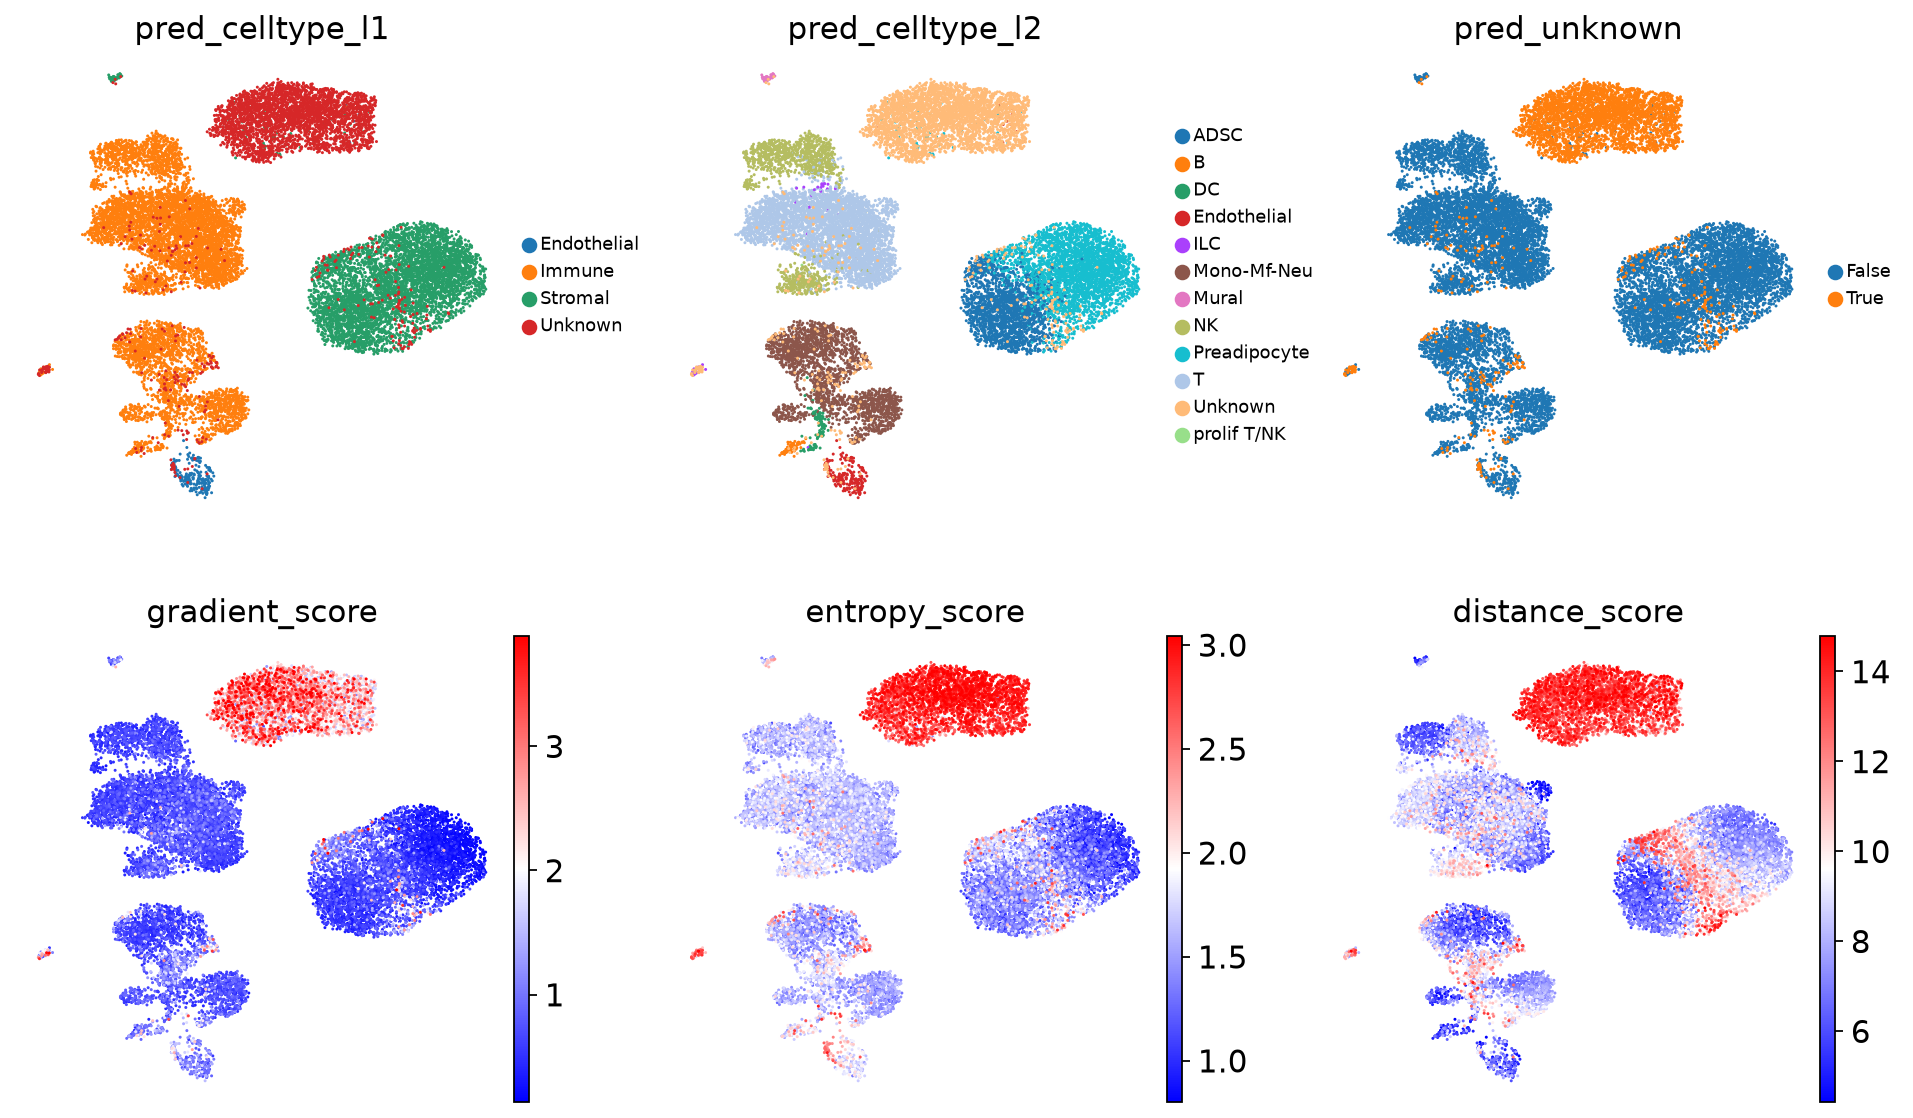

In [10]:
# Visualise prediction results with unknown cell type scores (gradient, entropy, distance)
sc.pl.umap(
    adata,
    color = [
        'pred_celltype_l1',
        'pred_celltype_l2',
        'pred_unknown',
        'gradient_score', # unknown cell type score
        'entropy_score', # unknown cell type score
        'distance_score' # unknown cell type score
    ],
    frameon = False,
    legend_fontsize = 8,
    ncols = 3,
    cmap = 'bwr',
    vmin = 'p01',
    vmax = 'p99'
)

Analysis of the scores indicates the presence of two additional cell types in visceral adipose tissue that are absent from subcutaneous adipose tissue.

The dataset already contains ground-truth cell-type annotations that were generated independently of scAdam predictions using marker genes. To compare the ground-truth annotations with the predicted annotations, we will recolor the cells so that the same cell types use the same colors in both visualizations.

In [11]:
# Define colors
color_map = {
    "ADSC": "#1f77b4",
    "T": "#ff7f0e",
    "NK": "#279e68",
    "ILC": "#d62728",
    "Mural": "#aa40fc",
    "Mono-Mf-Neu": "#8c564b",
    "Mesothelial": "#b5bd61",
    "Preadipocyte": "#17becf",
    "B": "#aec7e8",
    "Endothelial": "#ffbb78",
    "Mast": "#98df8a",
    "prolif T/NK": "#ff9896",
    "Unknown": "#c5b0d5"
}
default_color = "#bdbdbd"

# Recolor cells
celltype_col = 'ground_truth'
cats = list(adata.obs[celltype_col].cat.categories)
adata.uns[f"{celltype_col}_colors"] = [color_map.get(c, default_color) for c in cats]
celltype_col = 'pred_celltype_l2'
cats = list(adata.obs[celltype_col].cat.categories)
adata.uns[f"{celltype_col}_colors"] = [color_map.get(c, default_color) for c in cats]

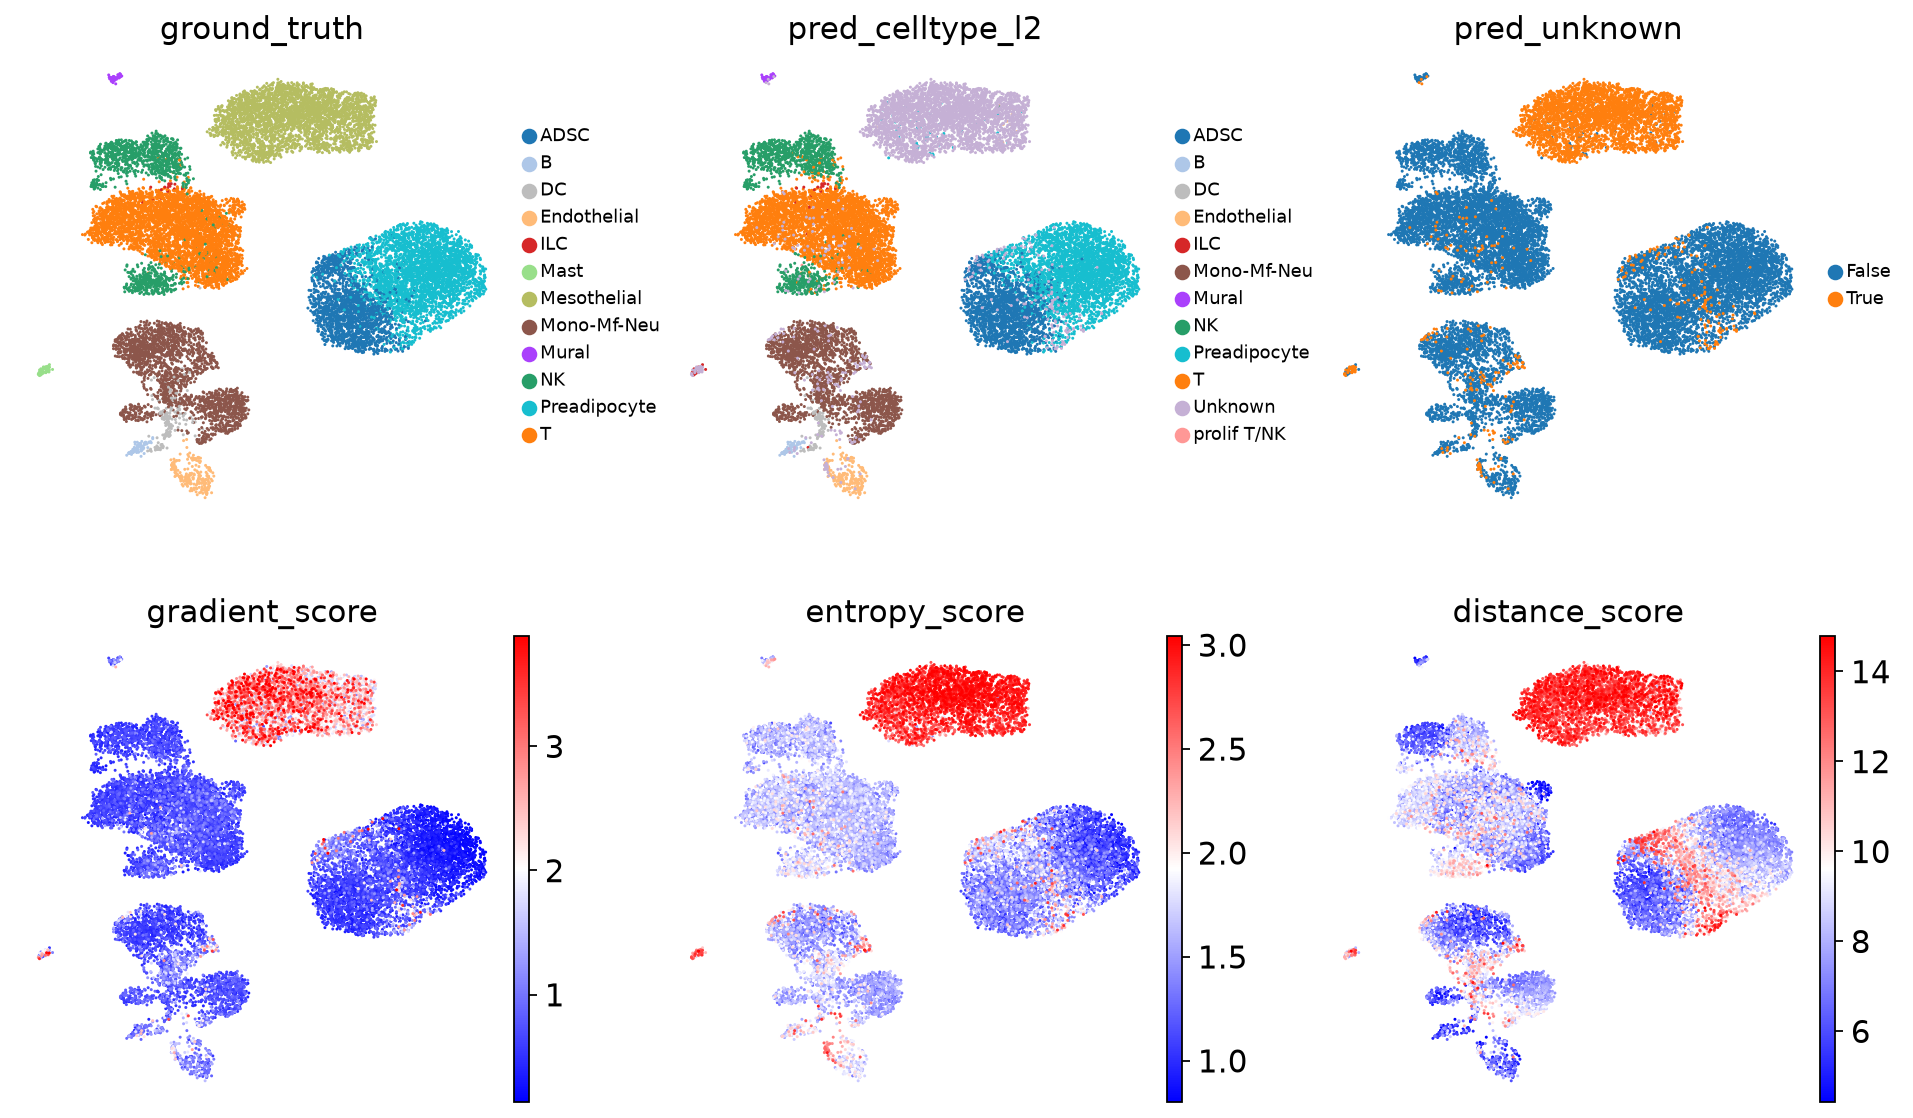

In [12]:
# Visualize ground_truth vs pred_celltype_l2
sc.pl.umap(
    adata,
    color = [
        'ground_truth',
        'pred_celltype_l2',
        'pred_unknown',
        'gradient_score', 
        'entropy_score', 
        'distance_score'
    ],
    frameon = False,
    legend_fontsize = 8,
    ncols = 3,
    cmap = 'bwr',
    vmin = 'p01',
    vmax = 'p99'
)

We recommend validating scAdam cell-type predictions using specific marker genes for the predicted cell types. Marker-gene expression is commonly used to assess whether automated annotations are biologically consistent.

In [13]:
marker_genes = {
    "ADSC": ['CD55', 'PI16'],
    "Preadipocyte": ['CXCL14', 'IGF1'],
    "B": ['MS4A1', 'BANK1'],
    "DC": ['FCER1A'],
    "Mono-Mf-Neu": ['C1QA', 'FOLR2'],
    "Endothelial": ['PECAM1', 'KDR', 'VWF'],
    "Mural": ['ACTA2', 'RGS5'],
    "ILC": ['IL2RA', 'KIT'],
    "Mast": ['TPSAB1', 'CPA3'],
    "Mesothelial": ['MSLN', 'UPK3B'],
    "NK": ['NCAM1', 'KLRF1', 'NKG7'],
    "T": ['CD3E', 'CD3G', 'CD3D'],
}

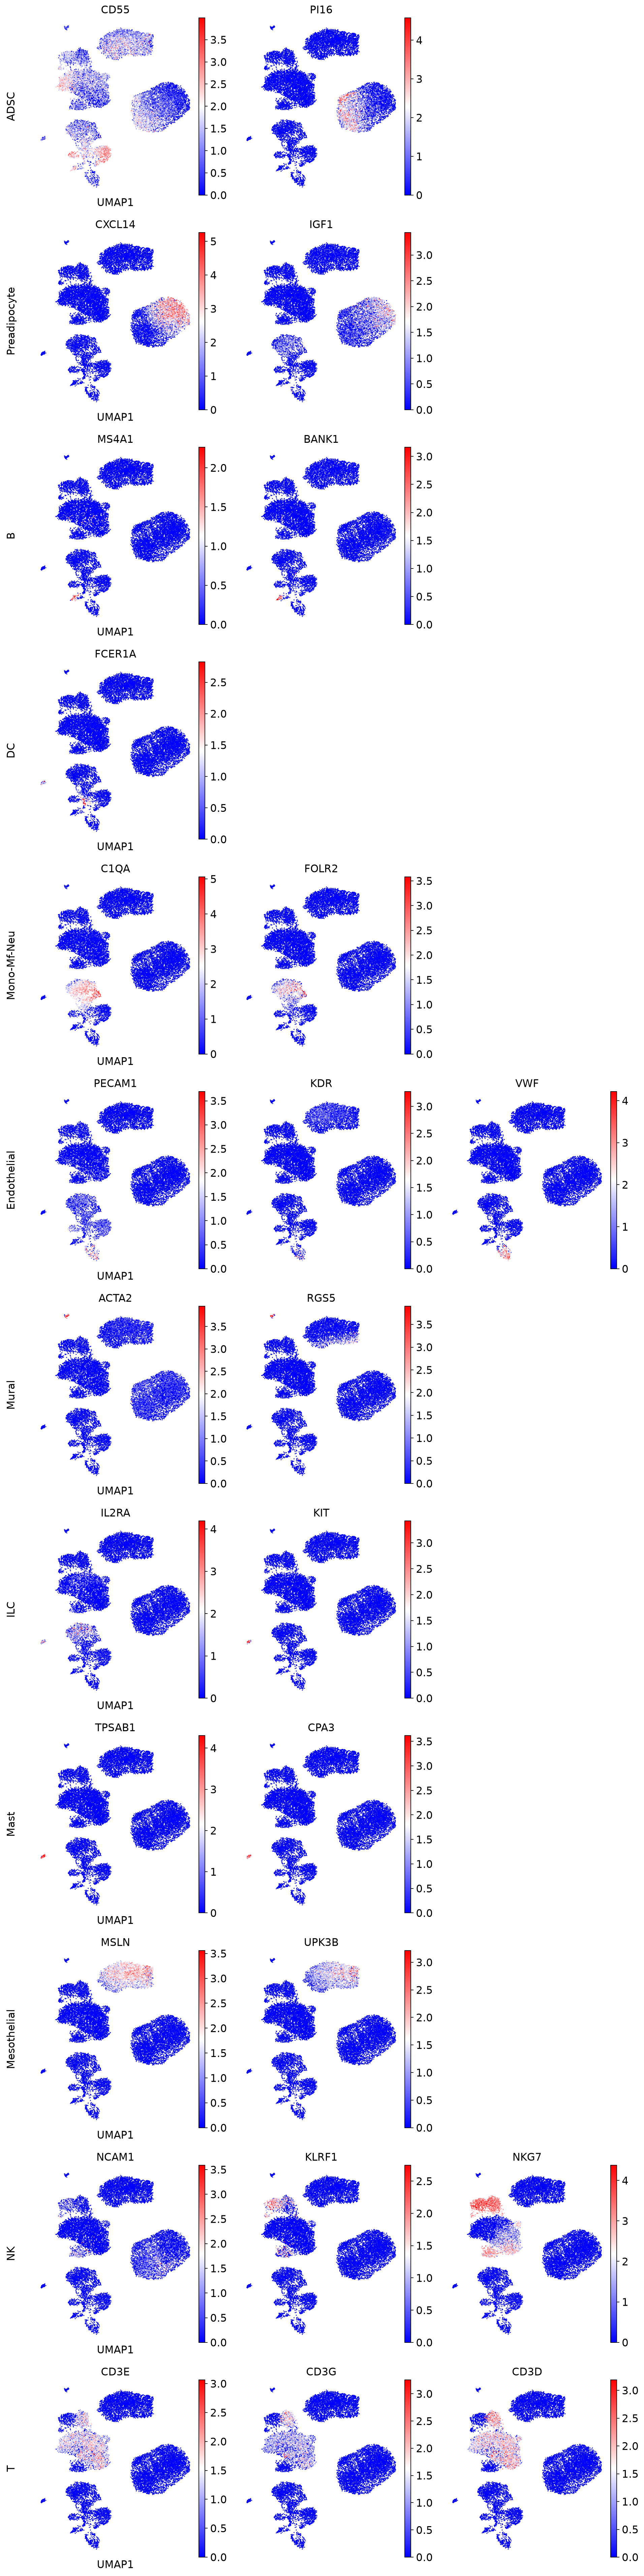

In [14]:
# Make Axes
# Number of needed rows and columns (based on the row with the most columns)
nrow = len(marker_genes)
ncol = max([len(vs) for vs in marker_genes.values()])
fig, axs = plt.subplots(nrow, ncol, figsize=(4 * ncol, 4 * nrow))
# Plot expression for every marker on the corresponding Axes object
for row_idx, (cell_type, markers) in enumerate(marker_genes.items()):
    col_idx = 0
    for marker in markers:
        ax = axs[row_idx, col_idx]
        sc.pl.umap(
            adata, 
            color=marker, 
            ax=ax, 
            show=False,
            cmap = 'bwr',
            frameon=False
        )
        # Add cell type as row label - here we simply add it as ylabel of
        # the first Axes object in the row
        if col_idx == 0:
            # We disabled axis drawing in UMAP to have plots without background and border
            # so we need to re-enable axis to plot the ylabel
            ax.axis("on")
            ax.tick_params(
                top="off",
                bottom="off",
                left="off",
                right="off",
                labelleft="on",
                labelbottom="off",
            )
            ax.set_ylabel(cell_type + "\n", rotation=90, fontsize=14)
            ax.set(frame_on=False)
        col_idx += 1
    # Remove unused column Axes in the current row
    while col_idx < ncol:
        axs[row_idx, col_idx].remove()
        col_idx += 1
# Alignment within the Figure
fig.tight_layout()

In [15]:
adata.write_h5ad('adata_predicted_with_unknown.h5ad')

In [16]:
import session_info2
session_info2.session_info()

Package,Version
pandas,2.3.3
anndata,0.12.16
scanpy,1.11.5
scparadise,1.2.0
numpy,2.4.6
matplotlib,3.11.0
Component,Info
Python,"3.11.15 (main, Jun 11 2026, 15:20:16) [GCC 14.3.0]"
OS,Linux-6.8.0-138-generic-x86_64-with-glibc2.39
Updated,2026-09-03 21:21
